# Learning a 3-channel selector for lentils (Gumbel-Softmax + AdaCLIP)

Hyperspectral cameras measure many bands (61 for the Ultris XMR lentils dataset), but most
vision anomaly detectors expect a 3-channel image. Reducing the cube to three channels lets
you run off-the-shelf, RGB-trained vision models on hyperspectral data as they are. Judged
purely by the information available, that is inferior to a model that consumes the complete
cube, but it is convenient and a quick stepping stone for trying state-of-the-art vision
models on your data. **Which three bands should represent the cube?** There is a ladder of
answers:

1. **RGB baseline**: a fixed visible triple, which washes out many foreign objects.
2. **Expert-picked, context-specific channels**: a hand-picked
   [CIR](https://docs.cuvis.ai/latest/catalogs/nodes/#cuvis_ai.node.channel_selector.CIRSelector "CIR = colour-infrared false colour: the near-infrared, red and green bands (860 / 670 / 560 nm here) shown as R, G and B") triple already helps a lot.
3. **Data-driven channel mixer** (this tutorial): the
   [lentils whitepaper](https://huggingface.co/datasets/cubert-gmbh/XMR_Industrial_Foreign_Object_Detection_Lentils/blob/main/whitepaper/lentils_hsi_whitepaper.pdf) went one step further and *learned* the
   triple from the data.
4. **The full cube**: the eventual goal, a detector that consumes all 61 bands and needs no
   selection at all.

This tutorial shows step 3 end to end:

- a **ConcreteChannelMixer** (Gumbel-Softmax / Concrete relaxation) holds logits over the 61
  bands and learns a hard 61 -> 3 selection,
- it is trained by backpropagating an **IoU loss through a frozen AdaCLIP detector** on the
  original lentils datasplit (plus a small distinctness loss so the three picks repel),
- at the end the notebook **prints and visualizes the three winning bands** and runs the
  trained pipeline so you can see the anomaly maps it produces.

The band pick depends on the data, the seed and the temperature schedule. The whitepaper run
landed on **[14, 59, 57] = 542 / 902 / 886 nm**, the "custom selector" consumed by the
champion Dinomaly pipeline in the sibling [`lentils_dinomaly.ipynb`](lentils_dinomaly.ipynb)
tutorial. The run baked into this notebook (same recipe, seed 42, reproduced on a second
machine with identical bands) landed on
**[40, 59, 58] = 750 / 902 / 894 nm**: it shares the two near-infrared bands with the
whitepaper and picks a different third band. Read the notebook as an illustration of how such
a triple is found, not as a bit-exact reproduction of the published one.

> **Prerequisites and footprint**
>
> 1. A cuvis-ai environment (`uv sync --extra dev` from the repo root, then `uv run jupyter lab`).
>    The provisioning cell right after the Colab bootstrap installs the plugins from the manifests
>    packaged with cuvis-ai via `uv run provision`: `cuvis-ai-dataloader[cu3s,coco]` (cu3s
>    reading, needs the Cuvis SDK), `cuvis-ai-adaclip` (the detector) and `cuvis-ai-dinomaly`,
>    installed only for its `AnomalyAUROCMetrics` node used in section 8 (a heavy install).
>    Restart the kernel after a fresh install.
> 2. Disk: the dataset snapshot is ~57 GB and is downloaded in full even for a dry run; the
>    converted per-frame NPZ files add ~140 MB per frame (~155 GB for all 1136 frames, ~10 GB
>    for the 72-frame dry run).
> 3. Time: the cu3s -> NPZ conversion runs at ~26 s per frame (~8 h for all 1136 frames; it
>    resumes, and it prints one line per cu3s session, so long silences are normal). The
>    20-epoch training took 10 h 16 min on a 12 GB laptop GPU (RTX 5070 Ti) with ~7 GB peak
>    allocated (~8 GB including the CUDA context), so a 12 GB card is enough.
> 4. Google Colab can only run the dry run (`MAX_EPOCHS = 1`, `CONVERT_LIMIT = 24`); the
>    bootstrap cell sets those defaults there.

In [1]:
# Colab bootstrap: a no-op when running locally.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # cuvis-ai itself; the next cell provisions the plugins from the packaged manifests.
    %pip install -q "cuvis-ai>=0.13.8"
    # The shared use_cases renderers, pinned to the commit that last touched them.
    !wget -q -O utils.py https://raw.githubusercontent.com/cubert-hyperspectral/cuvis-ai/b379f665fff20c627c259a624ec6911a0f8e015a/notebooks/use_cases/utils.py

    import torch

    if not torch.cuda.is_available():
        print("WARNING: No GPU detected. Switch via Runtime > Change runtime type > GPU.")

In [2]:
# Provision the plugins this notebook needs. Their pins live in the plugin manifests packaged with
# cuvis-ai (cuvis_ai/configs/plugins): `provision` reads them off a packaged pipeline that uses the
# same plugins, adds the data module's extras, and installs only what is missing. After a fresh
# install, restart the kernel (Kernel > Restart Kernel) and rerun from the top.
from importlib.resources import files

from cuvis_ai_core.utils.provision import provision_environment, resolve_install_specs

CONFIGS = files("cuvis_ai") / "configs"
PLUGINS_DIR = CONFIGS / "plugins"
PROVISION = [  # (packaged pipeline that lists the plugin(s), data module whose extras to add)
    ("anomaly/adaclip/concrete_adaclip_gradient_two_stage.yaml", "cu3s"),
    ("anomaly/dinomaly/dinomaly_cir_lentils.yaml", None),  # only for the AnomalyAUROCMetrics node
]
for pipeline_yaml, data_module in PROVISION:
    pipeline_path = CONFIGS / "pipeline" / pipeline_yaml
    if IN_COLAB:  # no uv project on Colab: pip the resolved specs straight into this kernel
        specs = resolve_install_specs(pipeline_path, [PLUGINS_DIR], data_module)
        provision_environment(specs, notebook=True, apply=True)
    else:  # the same command you would run in a terminal from the repo root
        data_arg = f"--data-module {data_module}" if data_module else ""
        !uv run provision --pipeline-path "{pipeline_path}" --plugins-dir "{PLUGINS_DIR}" {data_arg} --apply

In [3]:
%matplotlib inline
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from loguru import logger

# Robust import whether Jupyter's cwd is the repo root or this notebook folder.
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "utils.py").is_file():
    USE_CASES_DIR = NOTEBOOK_DIR
else:
    USE_CASES_DIR = NOTEBOOK_DIR / "notebooks" / "use_cases"
if str(USE_CASES_DIR) not in sys.path:
    sys.path.insert(0, str(USE_CASES_DIR))
REPO_ROOT = USE_CASES_DIR.parent.parent

from utils import iou, overlay_boundaries, to_uint8_rgb  # noqa: E402

logger.remove()
# The AdaCLIP plugin logs every forward pass at INFO (19k lines over a training run); keep
# that module at WARNING and everything else at INFO.
logger.add(
    sys.stderr, level="INFO", filter={"cuvis_ai_adaclip.adaclip_upstream": "WARNING", "": "INFO"}
)

device = (
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"device: {device}")

W0903 14:59:55.003000 6860 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device: cuda


## 1 - Dataset and objective

`cubert-gmbh/XMR_Industrial_Foreign_Object_Detection_Lentils`: 1136 frames of lentils on a
conveyor-belt background, captured with an Ultris XMR (61 bands, 430-910 nm, ~8 nm steps,
1000 x 1080 px). Foreign objects are annotated as semantic masks with 8 classes:

- `0` background / normal (lentils + belt)
- `1` stem_k, `2` stone, `3` alu_shard, `4` blue_paper, `5` white_paper, `6` fly, `7` rubber

Any non-zero class is treated as **anomalous** here. The official `splits.csv` datasplit is
train 808 (500 annotated + 308 normal), val 148, test 180; frames come in groups of four
lighting variants that always share a split, so nothing leaks between splits.

The selector below is trained **supervised** (it sees the train-split masks through the IoU
loss); the three bands it picks are then reused as a *fixed*, label-free front-end for
normal-only detectors such as Dinomaly.


## 2 - Knobs

One cell with everything you may want to change. The defaults are the **whitepaper recipe**
(full 808-frame train split, 20 epochs), which is what the baked outputs below were produced
with. It is a long run: about 10 h on a 12 GB laptop GPU (RTX 5070 Ti, ~7 GB peak), after the
one-off cu3s -> NPZ conversion (see the footprint note at the top). For a quick dry run that executes
end to end in minutes once the dataset is downloaded, set `MAX_EPOCHS = 1` and
`CONVERT_LIMIT = 24` (the band pick is then meaningless: too few frames and a single tau
step). Even at full scale the selected bands vary with the data, the seed and the schedule.

In [4]:
DATA_DIR = Path("/content/data") if IN_COLAB else REPO_ROOT / "data"  # dataset download root
NPZ_DIR = (
    DATA_DIR / "XMR_Industrial_Foreign_Object_Detection_Lentils_npz"
)  # NPZ + universe + splits
MAX_EPOCHS = 1 if IN_COLAB else 20  # whitepaper recipe: 20 (drives the tau anneal); dry run: 1
CONVERT_LIMIT = 24 if IN_COLAB else 0  # 0 = all frames (full split); dry run: 24 per split
BATCH_SIZE = 1
SEED = 42
N_RESULT_FRAMES = 3  # annotated test frames to visualize at the end

if IN_COLAB and CONVERT_LIMIT == 0:
    raise RuntimeError(
        "Colab disk cannot hold the full conversion (~155 GB); keep CONVERT_LIMIT > 0."
    )

## 3 - Get the data

Provisioning is the standard two lines: download the dataset once (the full ~57 GB snapshot,
also for a dry run), then convert the split manifest to per-frame NPZ plus the `universe.csv` /
`splits.json` pair the data module consumes. The conversion reads cu3s, so it needs the
`cuvis-ai-dataloader[cu3s]` extra (installed in the bootstrap cell). It logs one line per cu3s
session and ends with the frame count and the two artifact paths. Re-runs resume:
already-converted frames are skipped, so the cell is fast once the NPZ files exist.

In [5]:
from cuvis_ai_dataloader.data.npz_converter import convert_split_manifest

from cuvis_ai_core.data.public_datasets import PublicDatasets

PublicDatasets.download_dataset("Industrial_FOD_Lentils", download_path=str(DATA_DIR), force=False)
raw_dir = DATA_DIR / "XMR_Industrial_Foreign_Object_Detection_Lentils"

universe_csv = NPZ_DIR / "universe.csv"
splits_json = NPZ_DIR / "splits.json"
result = convert_split_manifest(
    raw_dir / "splits.csv",
    raw_dir,
    NPZ_DIR,
    universe_csv=universe_csv,
    splits_json=splits_json,
    limit=CONVERT_LIMIT,
)
print(result)

2026-09-03 14:59:56.924 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-11-01.cu3s -> 2 frame(s) into D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils_npz (all reused, cu3s not opened)
2026-09-03 14:59:56.980 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-31-31.cu3s -> 17 frame(s) into D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils_npz (all reused, cu3s not opened)


Dataset 'Industrial_FOD_Lentils' already exists at D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils
Use force=True to re-download.


2026-09-03 14:59:57.276 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-38-39.cu3s -> 81 frame(s) into D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils_npz (all reused, cu3s not opened)
2026-09-03 14:59:57.616 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_1.cu3s -> 96 frame(s) into D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils_npz (all reused, cu3s not opened)
2026-09-03 14:59:58.048 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_2.cu3s -> 136 frame(s) into D:\code-repos\cuvis-ai\wt-pr89-channel-selector\data\XMR_Industrial_Foreign_Object_Detection_Lentils_npz (all reused, cu3s not opened)
2026-09-03 14:59:58.245 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_15-2

SplitManifestOutputs(splits_json=WindowsPath('D:/code-repos/cuvis-ai/wt-pr89-channel-selector/data/XMR_Industrial_Foreign_Object_Detection_Lentils_npz/splits.json'), universe_csv=WindowsPath('D:/code-repos/cuvis-ai/wt-pr89-channel-selector/data/XMR_Industrial_Foreign_Object_Detection_Lentils_npz/universe.csv'))


In [6]:
# Per-channel wavelengths, read once from the first converted frame (all cubes share them).
# universe.csv stores `materialized_path` relative to its own directory, so resolve there.
with open(universe_csv, newline="", encoding="utf-8") as fh:
    universe_rows = list(csv.DictReader(fh))
first_npz = (universe_csv.parent / universe_rows[0]["materialized_path"]).resolve()
with np.load(first_npz) as npz:
    wavelengths = npz["wavelengths"].astype(float).ravel()
print(
    f"{len(universe_rows)} frames | {wavelengths.size} bands, "
    f"{wavelengths.min():.0f}-{wavelengths.max():.0f} nm"
)

1136 frames | 61 bands, 430-910 nm


### 3.1 - What the data looks like

One annotated frame, rendered three ways: a visible-light composite (650/550/450 nm), the
hand-picked CIR composite (860/670/560 nm), and the ground-truth mask on top of the visible
view (green = annotated foreign object). This is the problem in one figure: in the visible
composite the contaminants blend into the lentils; near-infrared bands separate them. The
selector's job is to find the three most useful bands automatically.


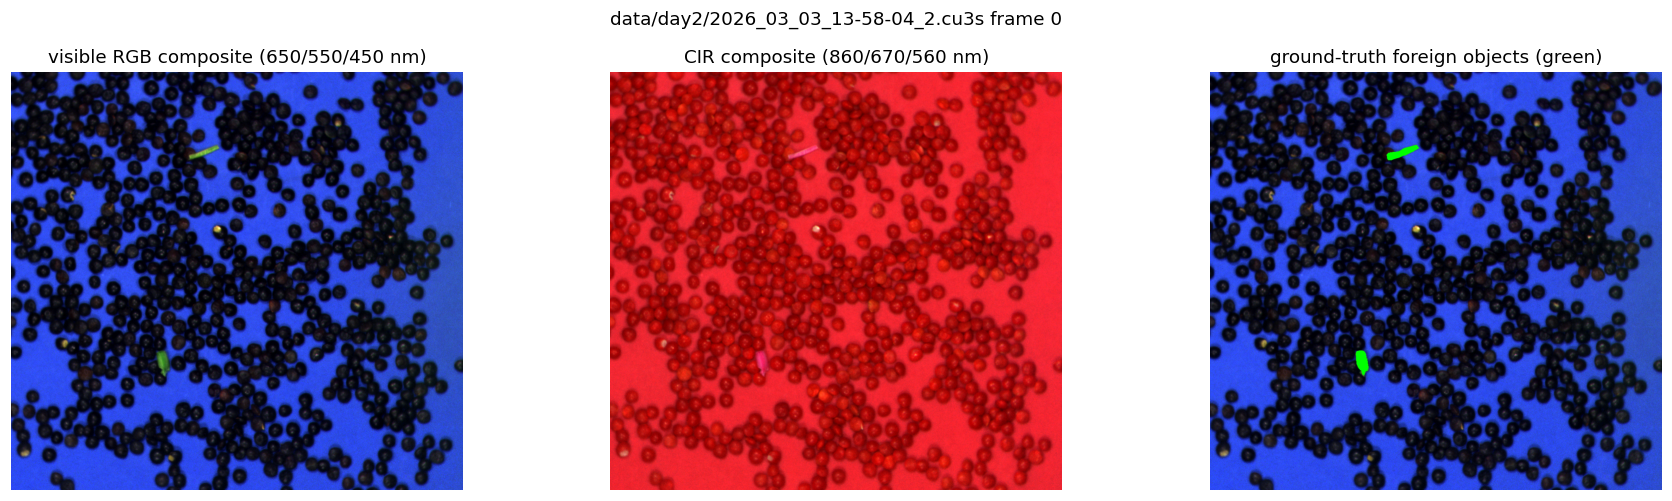

In [7]:
def band_index(nm: float) -> int:
    return int(np.argmin(np.abs(wavelengths - nm)))


def spectral_composite(cube: np.ndarray, targets_nm: tuple[float, float, float]) -> np.ndarray:
    img = np.stack([cube[:, :, band_index(nm)] for nm in targets_nm], axis=-1).astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0, 1)


def load_frame(row: dict) -> tuple[np.ndarray, np.ndarray]:
    with np.load((universe_csv.parent / row["materialized_path"]).resolve()) as npz:
        return npz["cube"].astype(np.float32), (np.asarray(npz["mask"]).squeeze() > 0)


# splits.json knows which frames are test; pick an annotated one for illustration
# (test frames first, then any frame, then simply the first frame).
splits_doc = json.loads(splits_json.read_text(encoding="utf-8"))
test_keys = {(sel["source"], int(i)) for sel in splits_doc["test"] for i in sel["ids"]}
test_rows = [r for r in universe_rows if (r["source"], int(r["index"])) in test_keys]

sample_row = universe_rows[0]
for candidate in [*test_rows, *universe_rows]:
    if load_frame(candidate)[1].any():
        sample_row = candidate
        break
cube, gt = load_frame(sample_row)

rgb_vis = spectral_composite(cube, (650.0, 550.0, 450.0))
cir_vis = spectral_composite(cube, (860.0, 670.0, 560.0))
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
ax[0].imshow(to_uint8_rgb(rgb_vis))
ax[0].set_title("visible RGB composite (650/550/450 nm)")
ax[1].imshow(to_uint8_rgb(cir_vis))
ax[1].set_title("CIR composite (860/670/560 nm)")
ax[2].imshow(overlay_boundaries(to_uint8_rgb(rgb_vis), np.zeros_like(gt), gt))
ax[2].set_title("ground-truth foreign objects (green)")
for a in ax:
    a.axis("off")
fig.suptitle(f"{sample_row['source']} frame {sample_row['index']}")
plt.tight_layout()
plt.show()

## 4 - The pipeline, node by node

- **AnomalyDataNode** adapts each batch: `cube [B,H,W,61]`, binary `mask` (any class > 0 is
  a foreign object), `wavelengths`.
- **MinMaxNormalizer** learns global min/max over the train stream (statistical phase).
- **ConcreteChannelMixer** is the lesson: per output channel c it keeps logits over the 61
  input bands and samples `softmax((logits_c + Gumbel)/tau)` during training. `tau` anneals
  `10.0 -> 0.1` across `MAX_EPOCHS`, so the soft mixture hardens into a (near) one-hot pick;
  at val/test it uses the hard `argmax` bands (`use_hard_inference=True`).
- **AdaCLIPDetector** (frozen, `enable_gradients=True`) turns the selected 3-channel image
  into pixel anomaly scores; gradients flow *through* it into the selector logits only.
- **IoULoss** (`normalize_method="minmax"`) is a soft IoU between the per-batch min-max
  normalized scores and the ground-truth masks. It is not the metric reported later: sections 7
  and 8 use a *thresholded* IoU behind the decider's image gate and pixel quantile, and normal
  frames (empty masks) contribute little gradient after min-max normalization.
  **DistinctnessLoss** (weight 0.1) penalizes the cosine similarity between the three selector
  rows so they do not collapse onto the same band; it knows nothing about wavelength distance,
  so neighbouring bands are not discouraged.
- **TwoStageBinaryDecider + AnomalyDetectionMetrics** report IoU/precision/recall during
  val; **ScoreHeatmapVisualizer + TensorBoardMonitorNode** log score maps per epoch.

In [8]:
from cuvis_ai_adaclip.node.adaclip_node import AdaCLIPDetector

from cuvis_ai.node.anomaly_visualization import ScoreHeatmapVisualizer
from cuvis_ai.node.channel_mixer import ConcreteChannelMixer
from cuvis_ai.node.data import AnomalyDataNode
from cuvis_ai.node.deciders.two_stage_decider import TwoStageBinaryDecider
from cuvis_ai.node.losses import DistinctnessLoss, IoULoss
from cuvis_ai.node.metrics import AnomalyDetectionMetrics
from cuvis_ai.node.monitor import TensorBoardMonitorNode
from cuvis_ai.node.normalization import MinMaxNormalizer

anomaly_data = AnomalyDataNode(normal_class_ids=[0], name="anomaly_data")
normalizer = MinMaxNormalizer(eps=1e-6, use_running_stats=True, name="MinMaxNormalizer")
concrete_selector = ConcreteChannelMixer(
    input_channels=int(wavelengths.size),  # 61 for the Ultris XMR
    output_channels=3,
    tau_start=10.0,
    tau_end=0.1,
    max_epochs=MAX_EPOCHS,  # the tau anneal spans the whole training run
    use_hard_inference=True,
    name="concrete_selector",
)
adaclip = AdaCLIPDetector(
    weight_name="pretrained_all",
    backbone="ViT-L-14-336",
    prompt_text="",
    image_size=518,
    prompting_depth=4,
    prompting_length=5,
    gaussian_sigma=4.0,
    use_half_precision=False,
    enable_warmup=False,
    enable_gradients=True,  # frozen weights, but gradients must flow through to the selector
    use_torch_preprocess=True,
    name="adaclip",
)
iou_loss = IoULoss(weight=1.0, smooth=1e-6, normalize_method="minmax", name="iou_loss")
distinctness_loss = DistinctnessLoss(weight=0.1, name="distinctness_loss")
decider = TwoStageBinaryDecider(
    image_threshold=0.24, top_k_fraction=0.001, quantile=0.995, name="decider"
)
metrics_anomaly = AnomalyDetectionMetrics(name="metrics_anomaly")
score_heatmap = ScoreHeatmapVisualizer(
    normalize_scores=True, cmap="inferno", up_to=3, name="score_heatmap"
)
tensorboard = TensorBoardMonitorNode(
    output_dir="outputs/channel_selector/tensorboard",
    run_name="concrete_adaclip_lentils",
    name="TensorBoardMonitorNode",
)

2026-09-03 17:24:26.982 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: outputs\channel_selector\tensorboard\concrete_adaclip_lentils
2026-09-03 17:24:26.983 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=outputs\channel_selector\tensorboard


In [9]:
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline

pipeline = CuvisPipeline("concrete_adaclip_lentils")

pipeline.connect(anomaly_data.outputs.cube, normalizer.inputs.data)
pipeline.connect(normalizer.outputs.normalized, concrete_selector.inputs.data)
pipeline.connect(concrete_selector.outputs.rgb, adaclip.inputs.rgb_image)

pipeline.connect(adaclip.outputs.scores, iou_loss.inputs.predictions)
pipeline.connect(anomaly_data.outputs.mask, iou_loss.inputs.targets)
pipeline.connect(
    concrete_selector.outputs.selection_weights, distinctness_loss.inputs.selection_weights
)

pipeline.connect(adaclip.outputs.scores, decider.inputs.logits)
pipeline.connect(adaclip.outputs.scores, metrics_anomaly.inputs.logits)
pipeline.connect(anomaly_data.outputs.mask, metrics_anomaly.inputs.targets)
pipeline.connect(decider.outputs.decisions, metrics_anomaly.inputs.decisions)

pipeline.connect(adaclip.outputs.scores, score_heatmap.inputs.scores)
pipeline.connect(metrics_anomaly.outputs.metrics, tensorboard.inputs.metrics)
pipeline.connect(score_heatmap.outputs.artifacts, tensorboard.inputs.artifacts)

pipeline.to(device)
pipeline

concrete_adaclip_lentils:
AnomalyDataNode(
  (_binary_mapper): BinaryAnomalyLabelMapper()
)
MinMaxNormalizer()
ConcreteChannelMixer()
AdaCLIPDetector()
IoULoss()
DistinctnessLoss()
TwoStageBinaryDecider()
AnomalyDetectionMetrics(
  (precision_metric): BinaryPrecision()
  (recall_metric): BinaryRecall()
  (f1_metric): BinaryF1Score()
  (iou_metric): BinaryJaccardIndex()
  (average_precision_metric): BinaryAveragePrecision()
)
ScoreHeatmapVisualizer()
TensorBoardMonitorNode()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

## 5 - Train: statistical phase, then gradient phase

`npz_multi` serves the converted frames through the frozen `splits.json` selectors, so the
run uses exactly the original datasplit. Training is the usual two-phase Cuvis.AI story:
the **StatisticalTrainer** fits data-derived state (the normalizer bounds) from the train
stream, then the **GradientTrainer** optimizes - after unfreezing **only** the selector.
The recipe mirrors the original trainrun: AdamW lr 1e-3 / weight-decay 0.01,
reduce-on-plateau on `metrics_anomaly/iou`, gradient clip 1.0.


In [10]:
import pytorch_lightning as pl
from cuvis_ai_dataloader.data.datamodule_npz_multi import MultiNpzDataModule
from cuvis_ai_schemas.training.data import DataSplitConfig

from cuvis_ai_core.training import GradientTrainer, StatisticalTrainer
from cuvis_ai_core.training.config import TrainingConfig

pl.seed_everything(SEED, workers=True)

datamodule = MultiNpzDataModule(
    splits=DataSplitConfig(splits_path=str(splits_json)),
    universe_csv=str(universe_csv),
    batch_size=BATCH_SIZE,
    num_workers=0,
)

StatisticalTrainer(pipeline=pipeline, datamodule=datamodule).fit()

pipeline.unfreeze_nodes_by_name(["concrete_selector"])  # everything else stays frozen

training_config = TrainingConfig.model_validate(
    {
        "seed": SEED,
        "max_epochs": MAX_EPOCHS,
        "accelerator": "auto",
        "devices": 1,
        "default_root_dir": "outputs/channel_selector",
        "precision": "32-true",
        "enable_progress_bar": False,  # static tutorial: keep the baked output readable
        "log_every_n_steps": 200,
        "check_val_every_n_epoch": 1,
        "gradient_clip_val": 1.0,
        "optimizer": {"name": "adamw", "lr": 1e-3, "weight_decay": 0.01, "betas": [0.9, 0.999]},
        "scheduler": {
            "name": "reduce_on_plateau",
            "monitor": "metrics_anomaly/iou",
            "mode": "max",
            "factor": 0.5,
            "patience": 5,
            "min_lr": 1e-6,
        },
    }
)
trainer = GradientTrainer(
    pipeline=pipeline,
    datamodule=datamodule,
    loss_nodes=[iou_loss, distinctness_loss],
    metric_nodes=[metrics_anomaly],
    training_config=training_config,
)
trainer.fit()

# The vendored AdaCLIP package switches matplotlib to Agg when the model loads; restore the
# notebook backend so the figures below render inline.
%matplotlib inline

Seed set to 42
2026-09-03 17:24:29.054 | INFO     | cuvis_ai_core.training.trainers:fit:559 - Training 1 statistical nodes...
2026-09-03 17:24:29.055 | INFO     | cuvis_ai_core.training.trainers:fit:567 -   Training MinMaxNormalizer...
Seed set to 42
2026-09-03 17:39:45.992 | INFO     | cuvis_ai_core.training.trainers:fit:148 - ============================================================
2026-09-03 17:39:45.992 | INFO     | cuvis_ai_core.training.trainers:fit:149 - Training: max_epochs=20, optimizer=adamw(lr=0.001)
2026-09-03 17:39:45.992 | INFO     | cuvis_ai_core.training.trainers:fit:158 - ============================================================
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pipeline_modules │ ModuleList │    183 │ train │     0 │
└───┴──────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 183                                                                                              
Non-trainable params: 0                                                                                            
Total params: 183                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

D:\code-repos\cuvis-ai\wt-pr89-channel-selector\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
D:\code-repos\cuvis-ai\wt-pr89-channel-selector\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
2026-09-03 17:39:48.172 | INFO     | cuvis_ai_adaclip.weights:download_weights:94 - Using cached AdaCLIP weights: C:\Users\nima.ghorbani\.cache\cuvis_ai\adaclip\pretrained_all.pth
2026-09-03 17:39:48.174 | INFO     | cuvis_ai_adaclip.adaclip_upstream:_init_model:107 - [cuvis_ai_adaclip] Initializing AdaCLIP with ViT-L-14-336 backbone on cuda:0...


**************************************************
Use pretrained model from openai...
**************************************************


2026-09-03 17:39:55.419 | INFO     | cuvis_ai_adaclip.adaclip_upstream:_init_model:171 - [cuvis_ai_adaclip] AdaCLIP initialized on cuda:0
2026-09-03 17:39:55.421 | INFO     | cuvis_ai_adaclip.adaclip_upstream:load_weights:181 - [cuvis_ai_adaclip] Loading AdaCLIP weights from C:\Users\nima.ghorbani\.cache\cuvis_ai\adaclip\pretrained_all.pth
2026-09-03 17:39:55.486 | INFO     | cuvis_ai_adaclip.adaclip_upstream:load_weights:221 - [cuvis_ai_adaclip] AdaCLIP weights loaded successfully
D:\code-repos\cuvis-ai\wt-pr89-channel-selector\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
D:\code-repos\cuvis-ai\wt-pr89-channel-selector\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_wor

## 6 - The three selected channels

The payoff: the selector's logits, hardened by the tau anneal, name three bands. The whitepaper
run converged to **indices [14, 59, 57] = 542 / 902 / 886 nm** (one green band plus two
near-infrared bands), which became the fixed "custom selector" of the champion Dinomaly
pipeline. The run baked here converged to **[40, 59, 58] = 750 / 902 / 894 nm**: the same two
NIR bands and a different third one. Note that channels 2 and 3 sit on adjacent bands (902 and
894 nm, one 8 nm step apart). The distinctness loss cannot prevent that: it measures the cosine
similarity of the selector rows, and two one-hot picks on neighbouring bands are already
maximally distinct to it. Enforcing spectral spacing would take a wavelength-aware regularizer.

In [11]:
bands = concrete_selector.get_selected_bands().tolist()
band_nm = [float(wavelengths[b]) for b in bands]

print("Selected band indices (channel 1, 2, 3):", bands)
print("Selected wavelengths [nm]:            ", [round(w, 1) for w in band_nm])
print()
print("Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,")
print("e.g. for the Dinomaly foreign-object detector:")
print()
print("    FixedWavelengthSelector(")
print(f"        target_wavelengths={[round(w, 1) for w in band_nm]},")
print("        normalize_output=True, apply_gamma=True,")
print("    )")
print()
print("Whitepaper run: indices [14, 59, 57] = 542 / 902 / 886 nm. The pick depends on the data,")
print("the epochs (tau anneal) and the seed; a dry run or another seed lands elsewhere.")

Selected band indices (channel 1, 2, 3): [40, 59, 58]
Selected wavelengths [nm]:             [750.0, 902.0, 894.0]

Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,
e.g. for the Dinomaly foreign-object detector:

    FixedWavelengthSelector(
        target_wavelengths=[750.0, 902.0, 894.0],
        normalize_output=True, apply_gamma=True,
    )

Whitepaper run: indices [14, 59, 57] = 542 / 902 / 886 nm. The pick depends on the data,
the epochs (tau anneal) and the seed; a dry run or another seed lands elsewhere.


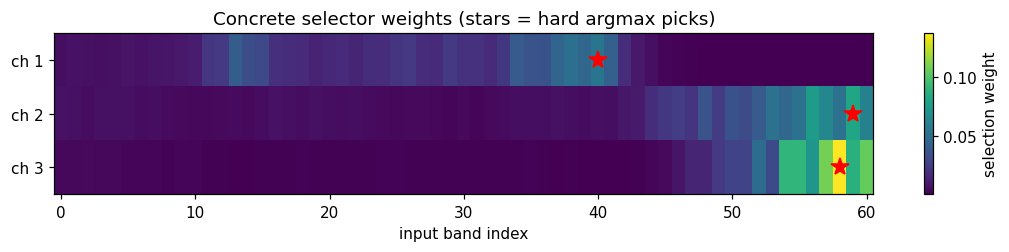

In [12]:
# The full selection-weight matrix: rows = output channels, columns = the 61 input bands.
weights = concrete_selector.get_selection_weights(deterministic=True).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 2.4), dpi=110)
im = ax.imshow(weights, aspect="auto", cmap="viridis")
ax.set_yticks(range(weights.shape[0]), [f"ch {i + 1}" for i in range(weights.shape[0])])
ax.set_xlabel("input band index")
for row, b in enumerate(bands):
    ax.plot(b, row, "r*", markersize=12)
fig.colorbar(im, ax=ax, label="selection weight")
ax.set_title("Concrete selector weights (stars = hard argmax picks)")
plt.tight_layout()
plt.show()

### 6.1 - What the detector actually sees

The same sample frame from section 3.1, rendered as the plain visible composite next to the
**learned 3-band composite**. The selected near-infrared bands lift the foreign objects out
of the lentil texture - this contrast is what the IoU loss optimized for.


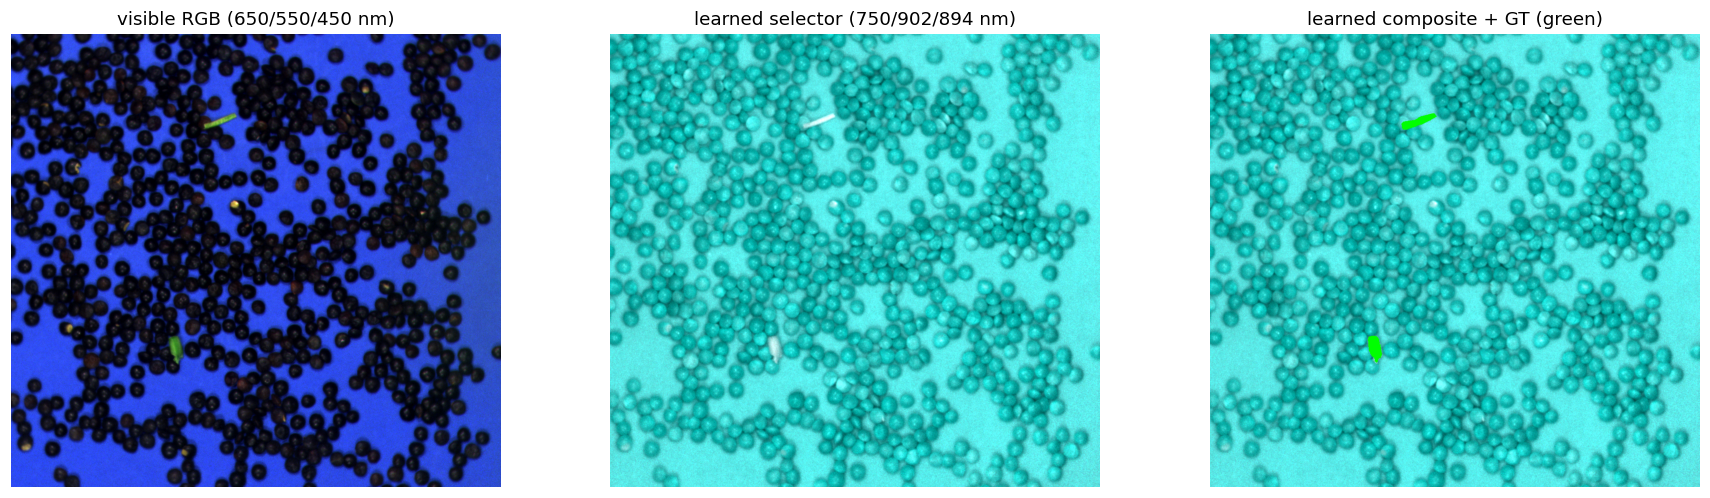

In [13]:
selected_vis = spectral_composite(cube, tuple(band_nm))
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
ax[0].imshow(to_uint8_rgb(rgb_vis))
ax[0].set_title("visible RGB (650/550/450 nm)")
ax[1].imshow(to_uint8_rgb(selected_vis))
ax[1].set_title(f"learned selector ({'/'.join(f'{w:.0f}' for w in band_nm)} nm)")
ax[2].imshow(overlay_boundaries(to_uint8_rgb(selected_vis), np.zeros_like(gt), gt))
ax[2].set_title("learned composite + GT (green)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## 7 - Run the trained pipeline: heatmaps and predicted masks

Now the whole pipeline runs as it would at inference (hard band selection active) through a
`Predictor` pass on a few test frames - the ones below contain annotated foreign objects, plus one normal frame. For
each frame we show:

- the selector's 3-channel output (the detector input),
- the dense AdaCLIP anomaly heatmap,
- the thresholded prediction against the ground truth.

Overlay colours: **green** = GT object pixels, **red** = predicted pixels, **yellow** =
overlap. The `TwoStageBinaryDecider` first gates each frame on its image-level score
(threshold 0.24, a hand-set demo value; section 8 explains what that means for the reported
IoU), so a clean frame yields an empty mask instead of the top-quantile speckle.

In [14]:
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.training.data import DataSplitConfig as _DSC

from cuvis_ai_core.training import Predictor

# A handful of test frames: N_RESULT_FRAMES annotated + 1 normal, selected via their masks.
anom_rows, normal_rows = [], []
for r in test_rows:
    (anom_rows if load_frame(r)[1].any() else normal_rows).append(r)
    if len(anom_rows) >= N_RESULT_FRAMES and normal_rows:
        break
result_rows = anom_rows[:N_RESULT_FRAMES] + normal_rows[:1]

by_source: dict[str, list[int]] = {}
for r in result_rows:
    by_source.setdefault(r["source"], []).append(int(r["index"]))
predict_splits = _DSC.model_validate(
    {
        "train": [],
        "val": [],
        "test": [],
        "predict": [
            {"kind": "file_indices", "source": s, "ids": sorted(ids)}
            for s, ids in sorted(by_source.items())
        ],
    }
)
predict_dm = MultiNpzDataModule(
    splits=predict_splits, universe_csv=str(universe_csv), batch_size=1, num_workers=0
)

# Inference is a Predictor pass: it puts the pipeline in eval mode, moves every batch to the
# pipeline's device and runs forward under no_grad at the requested stage. Lightning hands the
# module back on CPU after fit(), so move it to the GPU first. collect_ports keeps only the
# ports we plot, detached on CPU.
pipeline.to(device)
predictor = Predictor(pipeline=pipeline, datamodule=predict_dm)
outputs = predictor.predict(
    stage=ExecutionStage.INFERENCE,
    collect_outputs=True,
    collect_ports={"rgb", "scores", "decisions", "mask"},
)
print(f"ran {len(outputs)} frames")

Predict [concrete_adaclip_lentils]:   0%|          | 0/4 [00:00<?, ?batch/s]

2026-09-04 03:57:09.364 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.493s (493.2ms), batch_size=1, per_image=493.2ms
2026-09-04 03:57:11.089 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.403s (402.7ms), batch_size=1, per_image=402.7ms
2026-09-04 03:57:12.699 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.381s (381.7ms), batch_size=1, per_image=381.7ms
2026-09-04 03:57:14.349 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.388s (389.2ms), batch_size=1, per_image=389.2ms


ran 4 frames


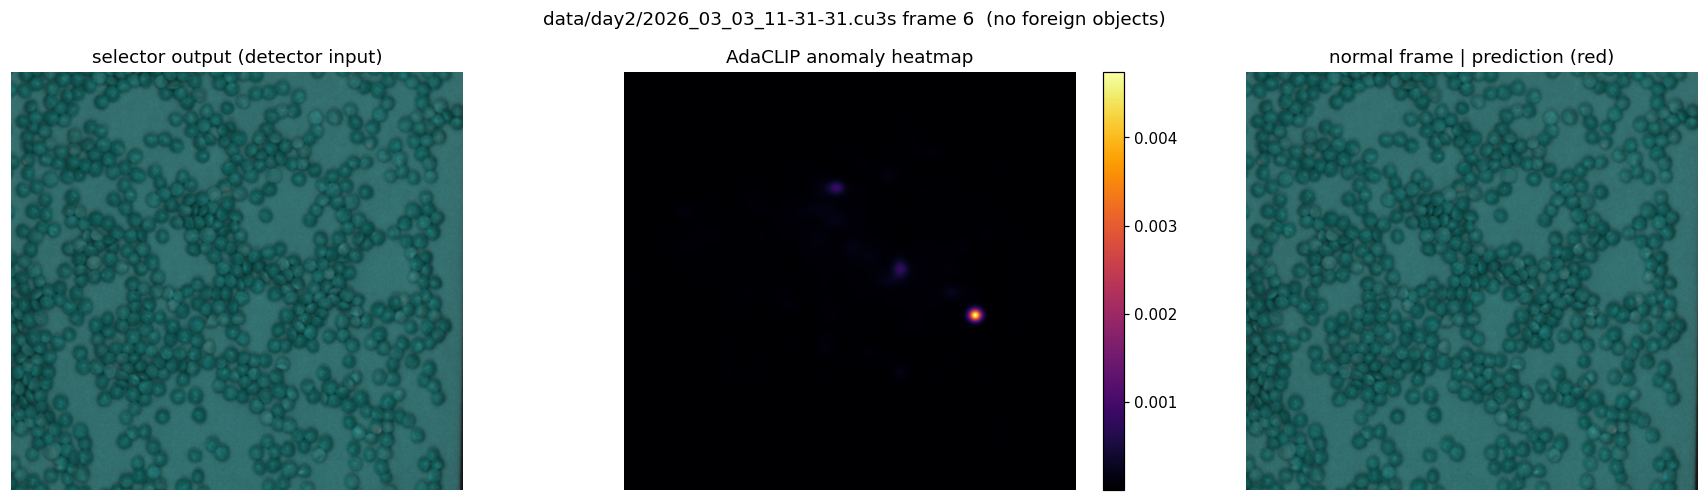

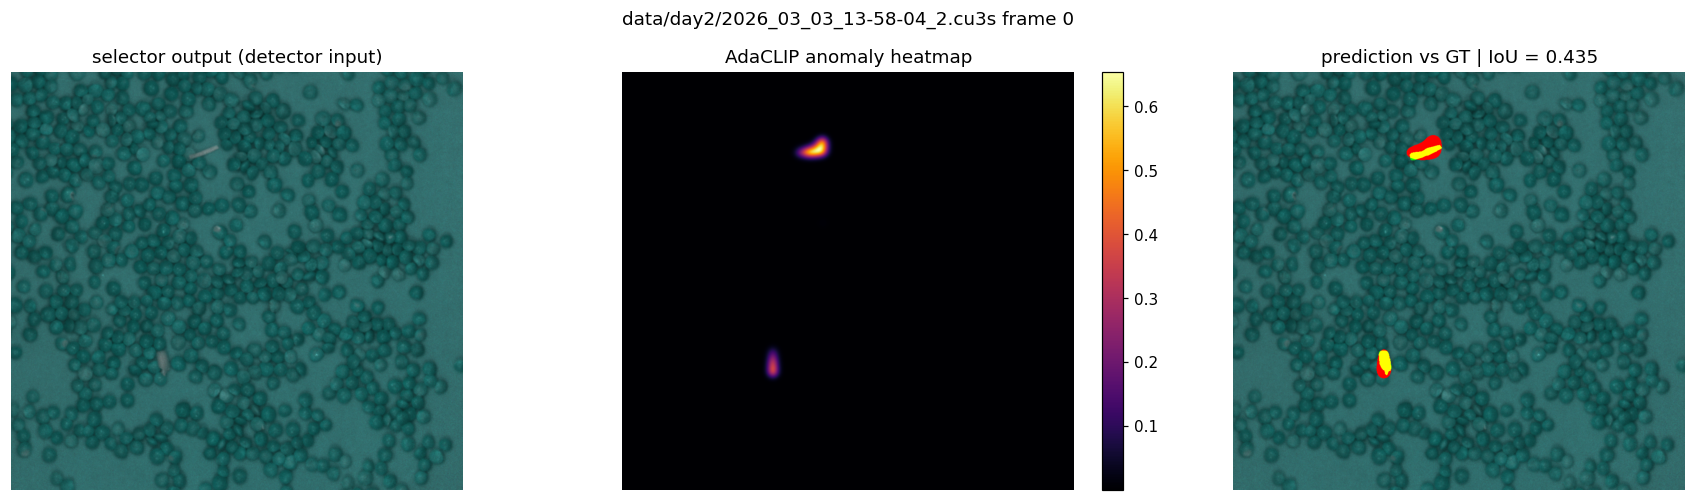

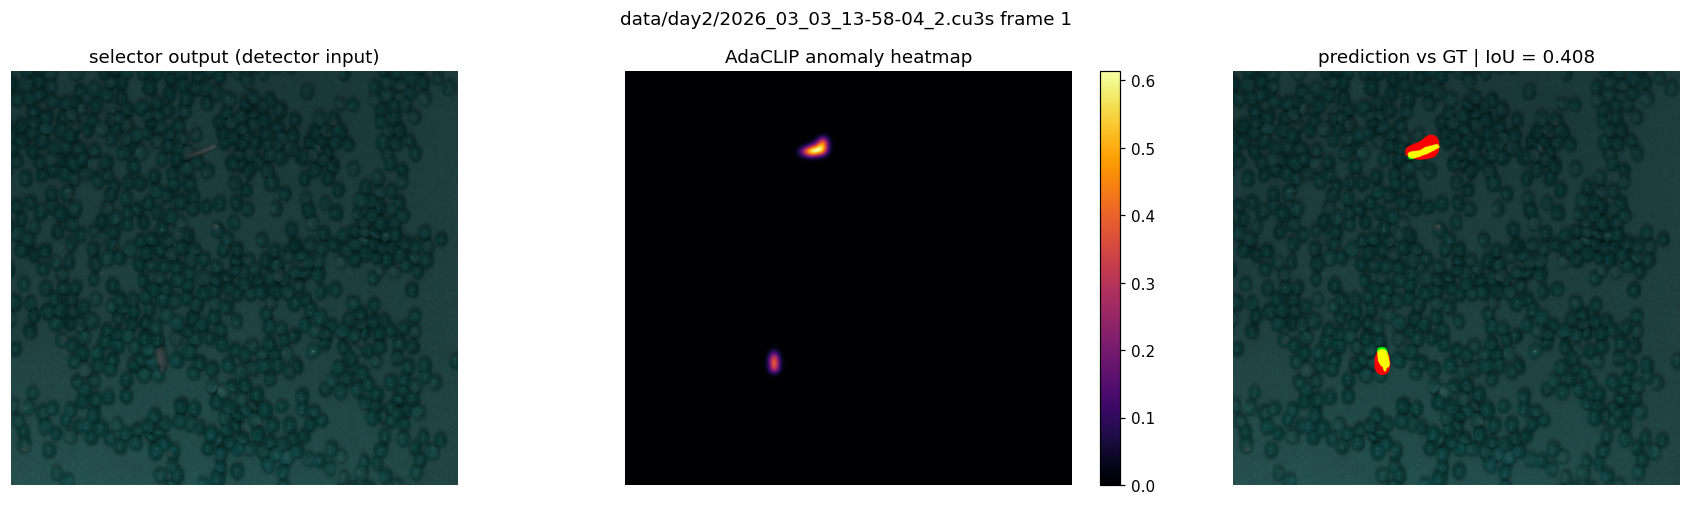

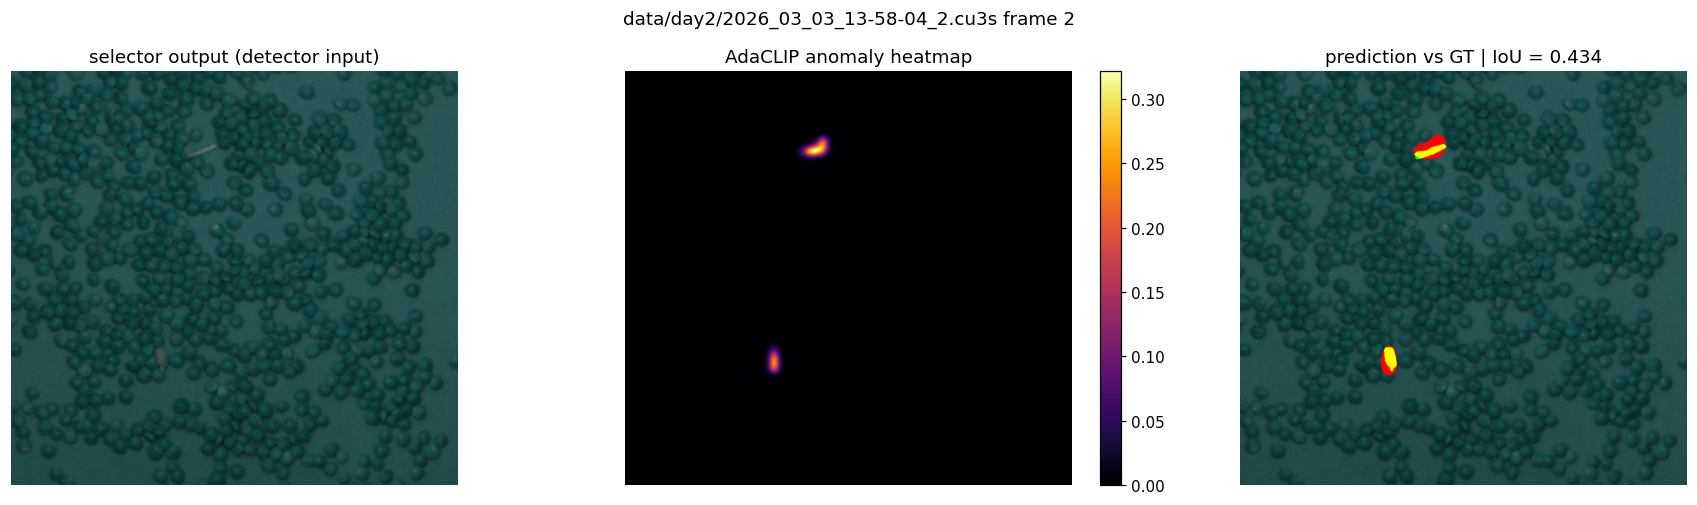

In [15]:
ordered = [(s, i) for s, ids in sorted(by_source.items()) for i in sorted(ids)]
for k, out in enumerate(outputs):
    ports = {port: v.squeeze().numpy() for (node, port), v in out.items()}
    rgb_in = ports["rgb"]
    scores = ports["scores"]
    pred = ports.get("decisions", np.zeros_like(scores)).astype(bool)
    gt_k = ports.get("mask", np.zeros_like(scores)).astype(bool)
    src, idx = ordered[k]

    fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
    ax[0].imshow(to_uint8_rgb(rgb_in))
    ax[0].set_title("selector output (detector input)")
    hm = ax[1].imshow(scores, cmap="inferno")
    ax[1].set_title("AdaCLIP anomaly heatmap")
    fig.colorbar(hm, ax=ax[1], fraction=0.046)
    ax[2].imshow(overlay_boundaries(to_uint8_rgb(rgb_in), pred, gt_k))
    ax[2].set_title(
        f"prediction vs GT | IoU = {iou(pred, gt_k):.3f}"
        if gt_k.any()
        else "normal frame | prediction (red)"
    )
    for a in ax:
        a.axis("off")
    fig.suptitle(f"{src} frame {idx}" + ("" if gt_k.any() else "  (no foreign objects)"))
    plt.tight_layout()
    plt.show()

## 8 - Test-set metrics

A single TEST-stage `Predictor` pass over the full test split, reading the numbers straight
off the metric nodes. `AnomalyDetectionMetrics` (wired in section 4) supplies pixel IoU and average
precision; an `AnomalyAUROCMetrics` node attached on top adds pixel and image AUROC.
Calling `.compute()` once at the end pools over every test pixel.

How to read the numbers: AUROC and average precision are threshold-free and come from
histogram-binned torchmetrics accumulators (`thresholds=200`), so they are close
approximations of the exact values. The IoU is a *thresholded* IoU that depends on the
decider's image gate (0.24) and pixel quantile (0.995); those were set by hand for this demo
(section 7), so treat the IoU as illustrative rather than as a tuned test score.

In [16]:
from cuvis_ai_dinomaly.node.auroc_metrics import AnomalyAUROCMetrics

# Attach an AUROC metric on top of the trained pipeline; AdaCLIP exposes anomaly_score for
# the image-level score. IoU / average precision stay on the metrics node from section 4.
auroc = AnomalyAUROCMetrics(thresholds=200, name="metrics_auroc")
pipeline.connect(adaclip.outputs.scores, auroc.inputs.scores)
pipeline.connect(adaclip.outputs.anomaly_score, auroc.inputs.anomaly_score)
pipeline.connect(anomaly_data.outputs.mask, auroc.inputs.targets)
pipeline.to(device)
auroc.to(device)  # a node attached after fit() is not covered by pipeline.to(device)

# The running IoU / AUROC accumulated over the training-val epochs; reset before the pass.
for _m in (
    metrics_anomaly.iou_metric,
    metrics_anomaly.average_precision_metric,
    auroc.pixel_auroc,
    auroc.image_auroc,
):
    _m.reset()

test_dm = MultiNpzDataModule(
    splits=_DSC.model_validate(
        {
            "train": [],
            "val": [],
            "test": [],
            "predict": [
                {"kind": "file_indices", "source": sel["source"], "ids": sel["ids"]}
                for sel in splits_doc["test"]
            ],
        }
    ),
    universe_csv=str(universe_csv),
    batch_size=1,
    num_workers=0,
)
# One TEST-stage Predictor pass: metric nodes only fire at VAL/TEST. Collecting the [B] image
# scores lets the frame count reflect what was actually processed.
test_outputs = Predictor(pipeline=pipeline, datamodule=test_dm).predict(
    stage=ExecutionStage.TEST, collect_outputs=True, collect_ports={"anomaly_score"}
)
n_seen = sum(int(o[("adaclip", "anomaly_score")].shape[0]) for o in test_outputs)

print(f"test frames  : {n_seen}")
print(f"pixel AUROC  : {float(auroc.pixel_auroc.compute()):.4f}")
print(f"image AUROC  : {float(auroc.image_auroc.compute()):.4f}")
print(f"IoU          : {float(metrics_anomaly.iou_metric.compute()):.4f}")
print(f"avg precision: {float(metrics_anomaly.average_precision_metric.compute()):.4f}")

Predict [concrete_adaclip_lentils]:   0%|          | 0/180 [00:00<?, ?batch/s]

2026-09-04 03:57:17.540 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.381s (383.0ms), batch_size=1, per_image=383.0ms
2026-09-04 03:57:19.355 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.402s (402.6ms), batch_size=1, per_image=402.6ms
2026-09-04 03:57:21.122 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.384s (384.8ms), batch_size=1, per_image=384.8ms
2026-09-04 03:57:22.807 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.410s (410.1ms), batch_size=1, per_image=410.1ms
2026-09-04 03:57:24.630 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.381s (382.3ms), batch_size=1, per_image=382.3ms
2026-09-04 03:57:26.389 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLI

test frames  : 180
pixel AUROC  : 0.9183
image AUROC  : 0.9085
IoU          : 0.2739
avg precision: 0.4875


## 9 - Where to go from here

- Drop the printed wavelengths into a `FixedWavelengthSelector` and train a normal-only
  **Dinomaly** pipeline on them - that exact hand-off is the sibling
  [`lentils_dinomaly.ipynb`](lentils_dinomaly.ipynb) tutorial, whose "custom selector"
  method uses the whitepaper bands from this recipe.
- A fixed 3-band representation is also a deployment story: a 3-filter multispectral
  sensor could replace the full hyperspectral acquisition for this task.
- Reproduction notes: the whitepaper-scale run is `MAX_EPOCHS = 20`, `CONVERT_LIMIT = 0`
  (full 808-frame train split); download, conversion and training costs are listed in the
  prerequisites at the top. The band pick is seed- and data-dependent (this baked run:
  750 / 902 / 894 nm; whitepaper: 542 / 902 / 886 nm), and a reduced dataset converges to
  different bands than the full split.